In [169]:
import numpy as np

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def bce(y_true, y_pred, eps=1e-12):
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [170]:
class Neuron:
    def __init__(self, n_inputs, weight_scale=0.1):
        self.w = np.random.randn(n_inputs) * weight_scale
        self.b = 0.0

    def forward(self, x):
        z = self.w @ x + self.b
        return sigmoid(z)

    def train(self, X, y, lr=0.01, epochs=5000):
        n = len(X)
        for epoch in range(epochs):
            dw = np.zeros_like(self.w)
            db = 0.0
            loss = 0.0

            for xi, yi in zip(X, y):
                y_pred = self.forward(xi)
                loss += bce(yi, y_pred)
                dz = y_pred - yi
                dw += dz * xi
                db += dz

            self.w -= lr * dw / n
            self.b -= lr * db / n

            if epoch % 1000 == 0:
                print(f"epoch={epoch}, loss={loss/n:.6f}")
    
    def predict(self, X):
        return np.array([1 if self.forward(x) >= 0.5 else 0 for x in X])
    
class Layer:
    def __init__(self, n_inputs, n_outputs, weight_scale=0.1):
        self.W = np.random.randn(n_inputs, n_outputs) * weight_scale
        self.b = np.zeros(n_outputs)

    def forward(self, X):
        self.X = X
        self.Z = X @ self.W + self.b
        self.A = sigmoid(self.Z)
        return self.A

    def backward(self, dZ):
        dW = self.X.T @ dZ
        db = np.sum(dZ, axis=0)
        dX = dZ @ self.W.T
        return dX, dW, db


class NeuralNetwork:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, y_true, y_pred):
        grads = []
        dZ = y_pred - y_true

        for i in reversed(range(len(self.layers))):
            layer = self.layers[i]
            dX, dW, db = layer.backward(dZ)
            grads.append((dW, db))
            if i > 0:
                prev = self.layers[i - 1]
                dZ = dX * sigmoid_derivative(prev.Z)

        grads.reverse()
        return grads

    def train(self, X, y, lr=0.01, epochs=5000, verbose_every=0):
        y = y.reshape(-1, 1)
        n = len(X)

        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = np.mean(bce(y, y_pred))
            grads = self.backward(y, y_pred)

            for layer, (dW, db) in zip(self.layers, grads):
                layer.W -= lr * (dW / n)
                layer.b -= lr * (db / n)

            if verbose_every and epoch % verbose_every == 0:
                print(f"epoch={epoch}, loss={loss:.6f}")
                
    def predict_proba(self, X):
        return self.forward(X).ravel()

    def predict(self, X, thr=0.5):
        return (self.predict_proba(X) >= thr).astype(int)

In [171]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
mask = iris.target != 0
X = iris.data[mask][:, 2:4]
y = (iris.target[mask] == 2).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 70, Test: 30


In [172]:
print("Один нейрон:")
from sklearn.metrics import classification_report, confusion_matrix

neuron = Neuron(n_inputs=2)
neuron.train(X_train, y_train, lr=0.1, epochs=5000)

y_pred_neuron = neuron.predict(X_test)
print(classification_report(y_test, y_pred_neuron))
print(confusion_matrix(y_test, y_pred_neuron))

Один нейрон:
epoch=0, loss=0.692870
epoch=1000, loss=0.314995
epoch=2000, loss=0.235951
epoch=3000, loss=0.199440
epoch=4000, loss=0.177641
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.93      0.87      0.90        15

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

[[14  1]
 [ 2 13]]


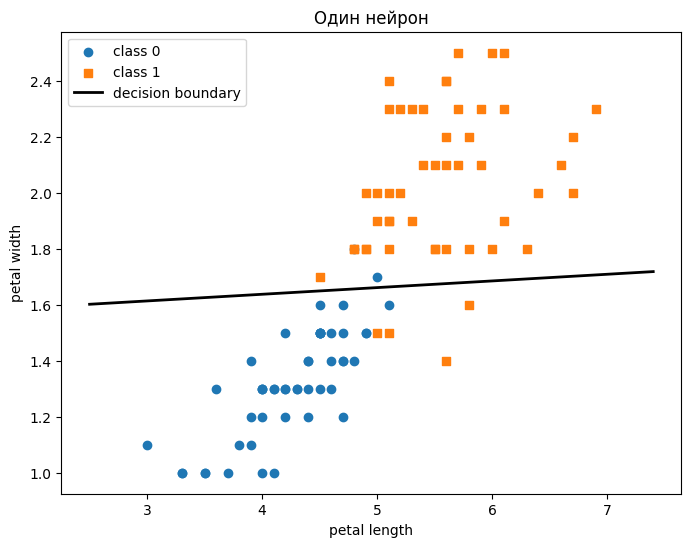

In [173]:
import matplotlib.pyplot as plt

def plot_neuron_boundary(neuron, X, y):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="class 0", marker="o")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="class 1", marker="s")

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    if abs(neuron.w[1]) > 1e-6:
        ys = -(neuron.w[0] * xs + neuron.b) / neuron.w[1]
        plt.plot(xs, ys, "k-", linewidth=2, label="decision boundary")
    else:
        plt.axvline(-neuron.b / neuron.w[0], color="black", linewidth=2)

    plt.xlabel("petal length")
    plt.ylabel("petal width")
    plt.legend()
    plt.title("Один нейрон")
    plt.show()

plot_neuron_boundary(neuron, X, y)

In [174]:
print("MLP 2x10")
neuronet = NeuralNetwork([
    Layer(2, 10),
    Layer(10, 10),
    Layer(10, 1),
])
neuronet.train(X_train, y_train, lr=0.05, epochs=5000, verbose_every=1000)

y_pred_net = neuronet.predict(X_test)
print(classification_report(y_test, y_pred_net))
print(confusion_matrix(y_test, y_pred_net))

MLP 2x10
epoch=0, loss=0.702796
epoch=1000, loss=0.692650
epoch=2000, loss=0.691684
epoch=3000, loss=0.688865
epoch=4000, loss=0.679089
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.93      0.93      0.93        15

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

[[14  1]
 [ 1 14]]


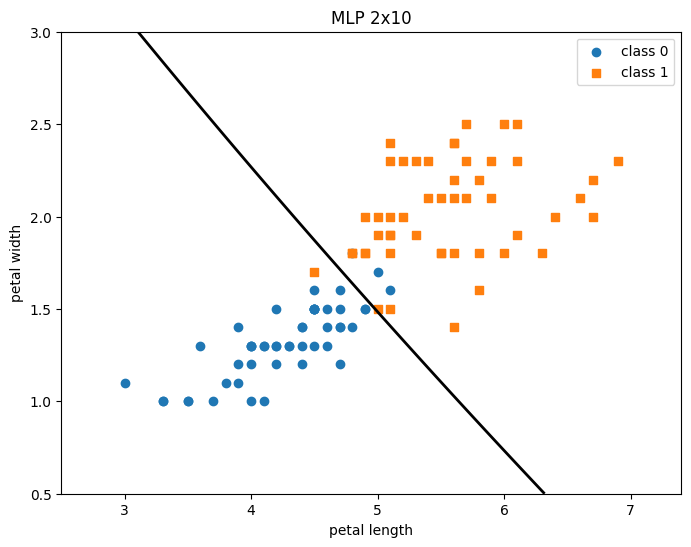

In [175]:
def plot_neuronet_boundary(neuronet: NeuralNetwork, X, y):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="class 0", marker="o")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="class 1", marker="s")

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    proba = neuronet.predict_proba(grid).reshape(xx.shape)

    plt.contour(xx, yy, proba, levels=[0.5], colors="black", linewidths=2)
    plt.xlabel("petal length")
    plt.ylabel("petal width")
    plt.legend()
    plt.title("MLP 2x10")
    plt.show()

plot_neuronet_boundary(neuronet, X, y)

MLP 2x10 оказалась точнее, чем один нейрон. Сеть сделала 2 ошибки, в то время как один нейрон сделал 3 ошибки. Помимо этого, у нейросети более сбалансированные значения precision, recall и F1-score. Получается, что нейросеть позволила повысить качество результата решения задачи квалификации